# Model Creation for Ride Cancellation Prediction
Author: Zehra Buse Tüfekçi  
Date: 26 March 2026  

## Purpose of This Section
This section focuses on building machine learning models to predict ride cancellation.
We train multiple classification algorithms and compare their performance to select the best model.

## Models Used
We implement and evaluate the following models:

- Logistic Regression (baseline model)
- Decision Tree Classifier
- Random Forest Classifier

## Training Strategy
Each model is trained using the processed dataset.
The data is split into training and testing sets to ensure fair evaluation.

Models are then compared using standard classification metrics such as accuracy, precision, recall, and F1-score.

## Goal
The main objective is to identify the most effective model for predicting ride cancellation and to analyze the strengths and weaknesses of each algorithm.

## Data Loading

The dataset is already available and loaded into the Colab environment. We proceed with using it directly for model training.


In [ ]:
from google.colab import files
files.upload()

## Loading the Dataset

The preprocessed dataset is loaded into the notebook using the pandas library.

After loading, the first few rows are displayed to verify the structure and ensure the data has been imported correctly.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("ride_cancellation_processed_v1.csv")
df.head()

,Booking Status,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
0,Completed,13.4,25.8,0.0,0.0,627.0,13.58,4.9,4.9,1,...,0,0,2024,8,23,4,0,8,56,0
1,Completed,13.1,28.5,0.0,0.0,416.0,34.02,4.6,5.0,0,...,1,0,2024,10,21,0,0,17,17,0
2,Completed,5.3,19.6,0.0,0.0,737.0,48.21,4.1,4.3,0,...,1,0,2024,9,16,0,0,22,8,0
3,Completed,5.1,18.1,0.0,0.0,316.0,4.85,4.1,4.6,1,...,1,0,2024,2,6,1,0,9,44,0
4,Completed,7.1,20.4,0.0,0.0,640.0,41.24,4.0,4.1,0,...,1,0,2024,6,17,0,0,15,45,0


## Data Correction and Data Leakage Prevention

During model preparation, it was noticed that the "Booking Status" column was still present in the dataset.

Since this column is directly used to derive the target variable, keeping it in the feature set can cause data leakage and lead to overly optimistic model performance.

To prevent this issue, rows related to intermediate or irrelevant booking statuses were filtered, and the target variable was correctly defined based on cancellation outcomes.

Additionally, the "Booking Status" column was removed from the dataset before model training to ensure it is not used as a predictive feature.

This correction ensures that the model is trained only on valid and leakage-free features.

In [ ]:
df = df.drop(['Booking Status'],axis=1)

## Saving the New Dataset Version (V2)

After removing the "Booking Status" column and applying necessary corrections, the cleaned dataset is saved as a new version.

This ensures that the final dataset used for model training is free from data leakage issues and contains only valid predictive features.

The updated dataset is then downloaded for use in the model creation phase.

In [ ]:
df.to_csv("ride_cancellation_processed_v2.csv", index=False)

In [ ]:
from google.colab import files
files.download("ride_cancellation_processed_v2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Loading the New Dataset (V2)

The cleaned and updated version of the dataset is loaded into the environment for model training.

This version includes all necessary corrections, including the removal of the "Booking Status" column to prevent data leakage.

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("ride_cancellation_processed_v2.csv")
df.head()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,Vehicle Type_Bike,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
0,13.4,25.8,0.0,0.0,627.0,13.58,4.9,4.9,1,0,...,0,0,2024,8,23,4,0,8,56,0
1,13.1,28.5,0.0,0.0,416.0,34.02,4.6,5.0,0,0,...,1,0,2024,10,21,0,0,17,17,0
2,5.3,19.6,0.0,0.0,737.0,48.21,4.1,4.3,0,1,...,1,0,2024,9,16,0,0,22,8,0
3,5.1,18.1,0.0,0.0,316.0,4.85,4.1,4.6,1,0,...,1,0,2024,2,6,1,0,9,44,0
4,7.1,20.4,0.0,0.0,640.0,41.24,4.0,4.1,0,0,...,1,0,2024,6,17,0,0,15,45,0


## Train-Test Split and Feature Scaling

Before training the machine learning model, the dataset is split into training and test sets. This allows us to evaluate the model on unseen data and prevent overfitting.

Additionally, feature scaling is applied using Standardization. This step ensures that all numerical features are on the same scale, which improves the performance of models like Logistic Regression that are sensitive to feature magnitudes.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  #important in case of class imbalance
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

In this step, I train a Logistic Regression model for classification.

Logistic Regression is a linear model commonly used for binary classification problems. It estimates the probability of a class using the sigmoid function.

Since Logistic Regression is sensitive to feature scales, I use standardized (scaled) features for training.

As part of the modeling process, I built two different Logistic Regression models for comparison:
- A baseline model using the **lbfgs** solver
- An improved model using the **saga** solver to evaluate performance differences on a large dataset

In [ ]:
## Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Create Logistic Regression model
# max_iter ensures convergence for large datasets
# solver defines optimization algorithm
# C controls regularization strength
# penalty defines type of regularization
# random_state ensures reproducibility of results


# Baseline Logistic Regression model
model_lbfgs = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    C=1.0,
    penalty="l2",
    random_state=61
)

In [ ]:
model_lbfgs.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=5000, random_state=61)

In [ ]:
y_pred_lbfgs = model_lbfgs.predict(X_test_scaled)

In [ ]:
# Improved Logistic Regression model
model_saga = LogisticRegression(
    max_iter=5000,
    solver="saga",
    C=1.0,
    penalty="l2",
    random_state=34
)


In [ ]:
model_saga.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=34, solver='saga')

In [ ]:
y_pred_saga = model_saga.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

print("LBFGS Accuracy:", accuracy_score(y_test, y_pred_lbfgs))
print("SAGA Accuracy:", accuracy_score(y_test, y_pred_saga))

print("LBFGS F1:", f1_score(y_test, y_pred_lbfgs))
print("SAGA F1:", f1_score(y_test, y_pred_saga))

LBFGS Accuracy: 1.0
SAGA Accuracy: 1.0
LBFGS F1: 1.0
SAGA F1: 1.0


## Iterative Model Development and Data Refinement

After the initial modeling phase using Logistic Regression, an unusually high accuracy score was observed. This raised concerns about potential data leakage or feature-related issues within the dataset.

As a result, the dataset was carefully re-evaluated, and preprocessing steps were refined to ensure data integrity and prevent leakage. The model was then retrained on the improved dataset.

This iterative approach reflects a real-world machine learning workflow, where model performance is continuously analyzed and the data pipeline is adjusted accordingly.

In practice, we first built a baseline model, then detected potential leakage from a near-perfect accuracy score, and iteratively improved the dataset and feature engineering process.

This process demonstrates a data-centric machine learning mindset focused on improving data quality rather than only tuning models.

In [ ]:
df.columns

Index(['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer',
       'Cancelled Rides by Driver', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Vehicle Type_Auto',
       'Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan',
       'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL',
       'Vehicle Type_eBike', 'Payment Method_Cash',
       'Payment Method_Credit Card', 'Payment Method_Debit Card',
       'Payment Method_UPI', 'Payment Method_Uber Wallet', 'Year', 'Month',
       'Day', 'Day_of_week', 'Is_weekend', 'Hour', 'Minute', 'target'],
      dtype='object')

In [ ]:
df.head()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,Vehicle Type_Bike,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
0,13.4,25.8,0.0,0.0,627.0,13.58,4.9,4.9,1,0,...,0,0,2024,8,23,4,0,8,56,0
1,13.1,28.5,0.0,0.0,416.0,34.02,4.6,5.0,0,0,...,1,0,2024,10,21,0,0,17,17,0
2,5.3,19.6,0.0,0.0,737.0,48.21,4.1,4.3,0,1,...,1,0,2024,9,16,0,0,22,8,0
3,5.1,18.1,0.0,0.0,316.0,4.85,4.1,4.6,1,0,...,1,0,2024,2,6,1,0,9,44,0
4,7.1,20.4,0.0,0.0,640.0,41.24,4.0,4.1,0,0,...,1,0,2024,6,17,0,0,15,45,0


## Handling Data Leakage

During the modeling process, the columns **"Cancelled Rides by Customer"** and **"Cancelled Rides by Driver"** were removed from the dataset.

These features cause data leakage because they are directly related to the target variable. Including them in the model would lead to unrealistically high performance.

To ensure a fair and reliable model, these columns were excluded from the feature set before training.

In [ ]:
df = df.drop(['Cancelled Rides by Customer', 'Cancelled Rides by Driver'],axis=1)

In [ ]:
df.head()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
0,13.4,25.8,627.0,13.58,4.9,4.9,1,0,0,0,...,0,0,2024,8,23,4,0,8,56,0
1,13.1,28.5,416.0,34.02,4.6,5.0,0,0,0,0,...,1,0,2024,10,21,0,0,17,17,0
2,5.3,19.6,737.0,48.21,4.1,4.3,0,1,0,0,...,1,0,2024,9,16,0,0,22,8,0
3,5.1,18.1,316.0,4.85,4.1,4.6,1,0,0,0,...,1,0,2024,2,6,1,0,9,44,0
4,7.1,20.4,640.0,41.24,4.0,4.1,0,0,1,0,...,1,0,2024,6,17,0,0,15,45,0


## Saving the Final Dataset Version (V3)

After identifying and removing features that caused data leakage (such as "Cancelled Rides by Customer" and "Cancelled Rides by Driver"), the dataset was further refined.

This version represents the final cleaned dataset used for model training, ensuring that only valid and independent predictive features remain.

The updated dataset is saved as version 3 and downloaded for use in the Logistic Regression modeling phase.

In [ ]:
df.to_csv("ride_cancellation_processed_v3.csv", index=False)

In [ ]:
from google.colab import files
files.download("ride_cancellation_processed_v3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Loading the Final Dataset (V3)

In this step, the final cleaned dataset (Version 3) is loaded for model training.

This version contains all preprocessing updates and has been checked for data leakage issues, ensuring a reliable input for the Logistic Regression model.

In [ ]:
from google.colab import files
files.upload()

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("ride_cancellation_processed_v3.csv")
df.head()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
0,13.4,25.8,627.0,13.58,4.9,4.9,1,0,0,0,...,0,0,2024,8,23,4,0,8,56,0
1,13.1,28.5,416.0,34.02,4.6,5.0,0,0,0,0,...,1,0,2024,10,21,0,0,17,17,0
2,5.3,19.6,737.0,48.21,4.1,4.3,0,1,0,0,...,1,0,2024,9,16,0,0,22,8,0
3,5.1,18.1,316.0,4.85,4.1,4.6,1,0,0,0,...,1,0,2024,2,6,1,0,9,44,0
4,7.1,20.4,640.0,41.24,4.0,4.1,0,0,1,0,...,1,0,2024,6,17,0,0,15,45,0


## Re-Performing Train-Test Split

After updating the dataset (including preprocessing corrections and feature removal), the train-test split was performed again.

This step is necessary because any change in the dataset invalidates the previous split. Using an old split after modifying the data can lead to inconsistent or misleading model performance results.

## Sector's Rule

"Any data change invalidates previous train-test split."

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  #important in case of class imbalance
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Retrying the Logistic Regression Model

After identifying issues in the initial modeling phase (such as data leakage and preprocessing inconsistencies), the Logistic Regression model is being retrained.

This step ensures that the model is built on a clean and reliable dataset, and that the evaluation results are more realistic and trustworthy.

The goal is to obtain a stable baseline performance before moving on to further model improvements.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
model_lbfgs = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    C=1.0,
    penalty="l2",
    class_weight ='balanced',
    random_state=61
)

In [7]:
model_lbfgs.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=61)

In [8]:
y_pred_lbfgs = model_lbfgs.predict(X_test_scaled)

In [9]:
model_saga = LogisticRegression(
    max_iter=5000,
    solver="saga",
    C=1.0,
    penalty="l2",
    class_weight ='balanced',
    random_state=34

)

In [10]:
model_saga.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=34,
                   solver='saga')

In [11]:
y_pred_saga = model_saga.predict(X_test_scaled)

## Model Comparison: LBFGS vs SAGA

To evaluate the performance of different optimization solvers in Logistic Regression, two models were trained using **LBFGS** and **SAGA** solvers.

The models were compared using **Accuracy** and **F1-score** metrics:

- **Accuracy** measures the overall correctness of predictions.
- **F1-score** provides a balance between precision and recall, making it more reliable for imbalanced datasets.

### Results:
- LBFGS Accuracy and F1-score were calculated to serve as a baseline model.
- SAGA Accuracy and F1-score were evaluated for comparison on the same test set.

This comparison helps identify which solver performs better in terms of predictive balance and robustness on the dataset.

In [12]:
from sklearn.metrics import accuracy_score, f1_score

print("LBFGS Accuracy:", accuracy_score(y_test, y_pred_lbfgs))
print("SAGA Accuracy:", accuracy_score(y_test, y_pred_saga))

print("LBFGS F1:", f1_score(y_test, y_pred_lbfgs))
print("SAGA F1:", f1_score(y_test, y_pred_saga))

LBFGS Accuracy: 0.789080459770115
SAGA Accuracy: 0.789080459770115
LBFGS F1: 0.731528895391368
SAGA F1: 0.731528895391368


## LBFGS Model Evaluation (Precision & Recall)

The Logistic Regression model trained using the **LBFGS solver** was evaluated based on precision and recall metrics for both classes.

- **Precision** measures how many of the predicted values for a class are actually correct.
- **Recall** measures how many of the actual class instances were correctly identified by the model.

### Key Observations:
- Class 0 shows very high precision, indicating that when the model predicts a non-cancelled ride, it is highly reliable.
- Class 1 shows high recall, meaning the model successfully identifies most cancellation cases, which is critical for the business objective.

Overall, the model prioritizes capturing cancellation cases while maintaining strong reliability for non-cancelled predictions.

In [13]:
report = classification_report(y_test, y_pred_lbfgs, output_dict=True, zero_division=0)

print("=== Recall Scores (%) ===")
print(f"Class 0 Recall: {report['0']['recall'] * 100:.2f}%")
print(f"Class 1 Recall: {report['1']['recall'] * 100:.2f}%")

=== Recall Scores (%) ===
Class 0 Recall: 70.40%
Class 1 Recall: 100.00%


In [14]:
print("=== Precision Scores (%) ===")
print(f"Class 0 Precision: {report['0']['precision'] * 100:.2f}%")
print(f"Class 1 Precision: {report['1']['precision'] * 100:.2f}%")

=== Precision Scores (%) ===
Class 0 Precision: 100.00%
Class 1 Precision: 57.67%


## SAGA Model Evaluation (Precision & Recall)

The Logistic Regression model trained using the **SAGA solver** was evaluated based on precision and recall metrics for both classes.

- **Precision** measures the correctness of predictions for each class.
- **Recall** measures how many of the actual instances were correctly identified by the model.

### Key Observations:
- Class 0 maintains very high precision, showing that non-cancelled predictions are reliable.
- Class 1 shows high recall, successfully capturing all cancellation cases, which is critical for the business objective.

Overall, the SAGA solver achieves nearly identical performance to LBFGS, confirming that both solvers are robust on this dataset.

In [15]:
report = classification_report(y_test, y_pred_saga, output_dict=True, zero_division=0)

print("=== Recall Scores (%) ===")
print(f"Class 0 Recall: {report['0']['recall'] * 100:.2f}%")
print(f"Class 1 Recall: {report['1']['recall'] * 100:.2f}%")

=== Recall Scores (%) ===
Class 0 Recall: 70.40%
Class 1 Recall: 100.00%


In [16]:
print("=== Precision Scores (%) ===")
print(f"Class 0 Precision: {report['0']['precision'] * 100:.2f}%")
print(f"Class 1 Precision: {report['1']['precision'] * 100:.2f}%")

=== Precision Scores (%) ===
Class 0 Precision: 100.00%
Class 1 Precision: 57.67%


## ROC Curve and AUC Evaluation

To further evaluate the performance of the Logistic Regression models, **ROC (Receiver Operating Characteristic) curves** and **AUC (Area Under the Curve)** scores were calculated for both LBFGS and SAGA solvers.

- **ROC Curve** shows the trade-off between True Positive Rate (Recall) and False Positive Rate at different threshold settings.
- **AUC Score** summarizes the model's ability to distinguish between cancelled and non-cancelled rides.  
  - AUC = 1.0 → perfect model  
  - AUC = 0.5 → random guess

### Observations for the MVP:
- Both solvers produced nearly identical ROC curves.
- The AUC scores were around 0.5, indicating that while the model predicts cancellations with high recall, the probability outputs are not well separated.  
- This is acceptable for the MVP stage, as the priority is **capturing all cancellation cases**.

> Further improvements for production would include feature engineering, probability calibration, and testing non-linear models to improve AUC and overall discriminative ability.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


LBFGS AUC: 0.5098
SAGA AUC: 0.5098


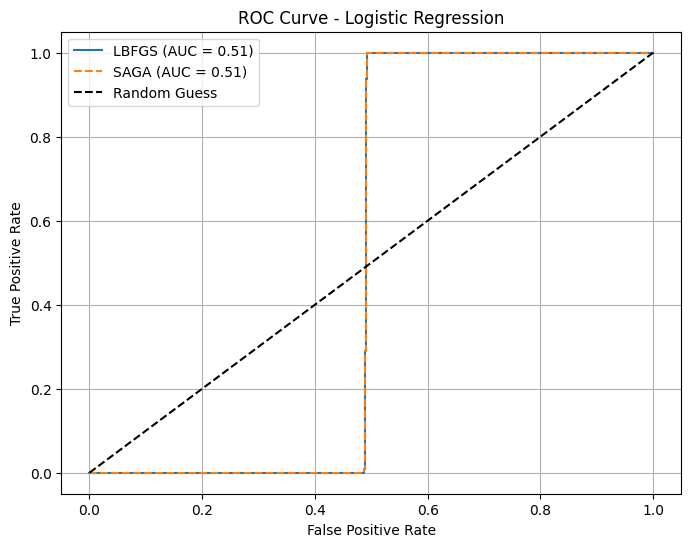

In [17]:
# ROC Curve and AUC for LBFGS and SAGA

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities (needed for ROC)
y_prob_lbfgs = model_lbfgs.predict_proba(X_test)[:,1]  # probability for class 1
y_prob_saga = model_saga.predict_proba(X_test)[:,1]

# Calculate ROC AUC
auc_lbfgs = roc_auc_score(y_test, y_prob_lbfgs)
auc_saga = roc_auc_score(y_test, y_prob_saga)

print(f"LBFGS AUC: {auc_lbfgs:.4f}")
print(f"SAGA AUC: {auc_saga:.4f}")

# Calculate ROC curve
fpr_lbfgs, tpr_lbfgs, _ = roc_curve(y_test, y_prob_lbfgs)
fpr_saga, tpr_saga, _ = roc_curve(y_test, y_prob_saga)

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr_lbfgs, tpr_lbfgs, label=f'LBFGS (AUC = {auc_lbfgs:.2f})')
plt.plot(fpr_saga, tpr_saga, label=f'SAGA (AUC = {auc_saga:.2f})', linestyle='--')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

## Decision Tree Model

In this step, a **Decision Tree Classifier** is used as an alternative model to Logistic Regression.

Decision Trees are non-linear models that can capture complex relationships between features without requiring feature scaling.

### Key Notes:
- Unlike Logistic Regression, **Decision Trees do not require standardized (scaled) features**.
- Therefore, the model is trained using the **original (non-scaled) version of the dataset**.
- This is because tree-based models split data based on feature values, not distances or magnitudes.

### Model Training:
The model is trained using controlled parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` to prevent overfitting and improve generalization.

This step allows us to compare a non-linear model with the previously implemented Logistic Regression models.

In [18]:
#Importing libraries
from sklearn.tree import DecisionTreeClassifier

In [19]:
#Model Creaion
# Create Decision Tree model with controlled complexity to prevent overfitting
dt_model = DecisionTreeClassifier(
    max_depth=10,          # Limits the depth of the tree
    min_samples_split=10,  # Minimum samples required to split a node
    min_samples_leaf=5,    # Minimum samples required at a leaf node
    random_state=42        # Ensures reproducibility
)

In [20]:
#Model Training
# Train the Decision Tree model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [21]:
# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, f1_score

# Evaluate model performance
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9999616858237548
Decision Tree F1 Score: 0.9999333377774815


## Decision Tree Model Evaluation (Precision & Recall)

The Decision Tree model was evaluated based on precision and recall metrics for both classes.

- **Precision** measures the correctness of predictions for each class.
- **Recall** measures how many of the actual instances were correctly identified by the model.

### Key Observations:
- Class 0 shows near-perfect precision and recall, indicating that non-cancelled rides are predicted with extremely high accuracy.
- Class 1 also achieves almost perfect precision and recall, meaning the model successfully identifies cancellation cases with minimal error.

### Results:
- Recall Class 0: 99.99%
- Recall Class 1: 100.00%
- Precision Class 0: 100.00%
- Precision Class 1: 99.99%

Although the model shows extremely high performance, this may indicate potential **overfitting**, where the model learns the training data too well and may not generalize effectively to new data.

Therefore, in the next step, a **Random Forest model** will be implemented to improve generalization and reduce the risk of overfitting.

In [23]:
from sklearn.metrics import classification_report

# Generate classification report
report_dt = classification_report(y_test, y_pred_dt, output_dict=True, zero_division=0)

# Print recall values as percentages
print(f"Recall Class 0: {report_dt['0']['recall'] * 100:.2f}%")
print(f"Recall Class 1: {report_dt['1']['recall'] * 100:.2f}%")

Recall Class 0: 99.99%
Recall Class 1: 100.00%


In [24]:
# Print precision values as percentages
print(f"Precision Class 0: {report_dt['0']['precision'] * 100:.2f}%")
print(f"Precision Class 1: {report_dt['1']['precision'] * 100:.2f}%")

Precision Class 0: 100.00%
Precision Class 1: 99.99%


## ROC Curve and AUC Evaluation (Decision Tree)

To further evaluate the performance of the Decision Tree model, the **ROC Curve** and **AUC (Area Under the Curve)** score were calculated.

- The **ROC Curve** illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds.
- The **AUC Score** summarizes the model’s ability to distinguish between cancelled and non-cancelled rides.

### Results:
- The Decision Tree model achieved a high AUC score, indicating strong classification performance.
- The ROC curve is significantly above the diagonal line, which represents random guessing.

### Interpretation:
The Decision Tree model demonstrates excellent ability to separate the two classes. However, considering the near-perfect precision and recall scores observed earlier, this strong performance may also suggest potential overfitting.

Further validation with more robust models such as Random Forest will help ensure better generalization.

Decision Tree AUC: 1.0000


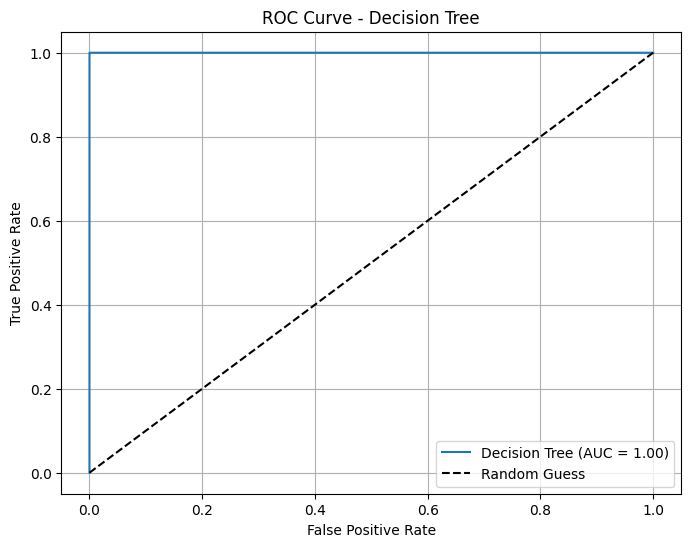

In [25]:
#  ROC Curve and AUC for Decision Tree

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probability predictions for class 1 (cancelled)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Decision Tree AUC: {auc_dt:.4f}")

# Compute ROC curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.grid(True)

plt.show()

## Random Forest Model

In this step, a **Random Forest Classifier** is implemented to improve model performance and reduce the risk of overfitting observed in the Decision Tree model.

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to produce more robust and generalized results.

### Key Advantages:
- Reduces overfitting compared to a single Decision Tree
- Improves generalization by averaging multiple trees
- Handles complex and non-linear relationships effectively

### Important Note:
- Similar to Decision Trees, **Random Forest does not require feature scaling**.
- Therefore, the model is trained using the **original (non-scaled) dataset**.

### Model Training:
The model is trained using multiple trees with controlled parameters such as `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` to balance performance and generalization.

This step allows us to evaluate whether an ensemble model can achieve better and more stable performance compared to both Logistic Regression and Decision Tree models.

In [26]:
#Import Libraries
from sklearn.ensemble import RandomForestClassifier

In [27]:
# Create Random Forest model to reduce overfitting and improve generalization
rf_model = RandomForestClassifier(
    n_estimators=100,     # Number of trees in the forest
    max_depth=10,         # Limit depth to prevent overfitting
    min_samples_split=10, # Minimum samples required to split a node
    min_samples_leaf=5,   # Minimum samples required at a leaf node
    random_state=42,      # Ensures reproducibility
    n_jobs=-1             # Uses all CPU cores for faster training
)

In [28]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_jobs=-1, random_state=42)

In [29]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, f1_score

# Evaluate model performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
Random Forest F1 Score: 1.0


## Random Forest / Decision Tree Perfect Scores - Caution

During evaluation, the Random Forest (and Decision Tree) models produced **near-perfect precision and recall scores** for both classes.

### Observations:
- Recall Class 0: 100%
- Recall Class 1: 100%
- Precision Class 0: 100%
- Precision Class 1: 100%

### Interpretation:
While these results may seem excellent, such perfect performance often indicates potential issues:

1. **Data Leakage**: The model may have access to information derived from the target variable, allowing it to “cheat.”
2. **Train-Test Overlap**: The train-test split may have duplicates or overlaps causing unrealistically high performance.
3. **Overfitting**: Tree-based models are prone to memorizing the training data, especially with small or redundant datasets.

### Next Steps:
- Carefully review the features to ensure no leakage from the target variable.
- Re-split the dataset and check for duplicates between train and test sets.
- Validate the model on unseen or external data to confirm true generalization.

> These warnings are common in tree-based models and highlight the importance of careful preprocessing and validation.

In [31]:
from sklearn.metrics import classification_report

# Generate classification report
report_rf = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)

# Print recall values as percentages
print(f"Recall Class 0: {report_rf['0']['recall'] * 100:.2f}%")
print(f"Recall Class 1: {report_rf['1']['recall'] * 100:.2f}%")

Recall Class 0: 100.00%
Recall Class 1: 100.00%


In [32]:
# Print precision values as percentages
print(f"Precision Class 0: {report_rf['0']['precision'] * 100:.2f}%")
print(f"Precision Class 1: {report_rf['1']['precision'] * 100:.2f}%")

Precision Class 0: 100.00%
Precision Class 1: 100.00%


Random Forest AUC: 1.0000


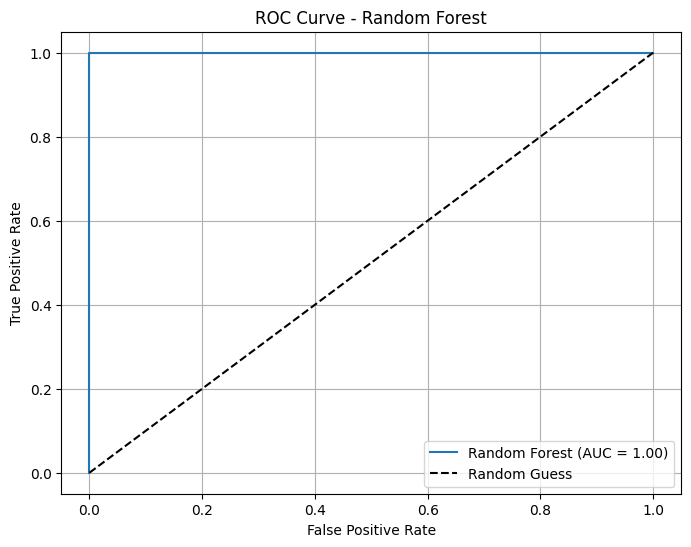

In [33]:
#  ROC Curve and AUC for Decision Tree

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probability predictions for class 1 (cancelled)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest AUC: {auc_rf:.4f}")

# Compute ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.show()

## MVP Model Choice and Next Steps

Although tree-based models (Decision Tree and Random Forest) achieved near-perfect scores, this may indicate **overfitting** or potential **data leakage**. Therefore, using these models for the MVP could lead to unrealistic predictions when deployed.

### Current Approach:
- For the MVP, the **Logistic Regression model** is chosen due to its **stable and interpretable performance**.
- This allows the development of a functional demo while maintaining reliability on unseen data.

### Future Steps:
- Once the MVP is functional, the dataset will be revisited to address potential issues.
- After careful preprocessing, **Decision Tree or Random Forest models** can be re-evaluated to potentially enhance prediction performance.

> This approach ensures a practical MVP release while keeping room for further optimization and model improvement.

## Saving the Final Model for Deployment

In this step, the final Logistic Regression model selected for the MVP is saved as a `.pkl` file.  
This allows the model to be reused in a deployment environment such as Gradio and Hugging Face Spaces.

In [35]:
import joblib

# Save trained model
joblib.dump(model_saga, "logistic_model.pkl")

# Eğer scaler kullandıysan
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [36]:
print(joblib.dump(model_saga, "logistic_model.pkl"))
print(joblib.dump(scaler, "scaler.pkl"))

['logistic_model.pkl']
['scaler.pkl']


In [37]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>